<a href="https://colab.research.google.com/github/rabicenkonikita3-cloud/python-practice-algos/blob/master/%D0%A0%D1%8F%D0%B1%D0%B8%D1%87%D0%B5%D0%BD%D0%BA%D0%BE_636_01_housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population

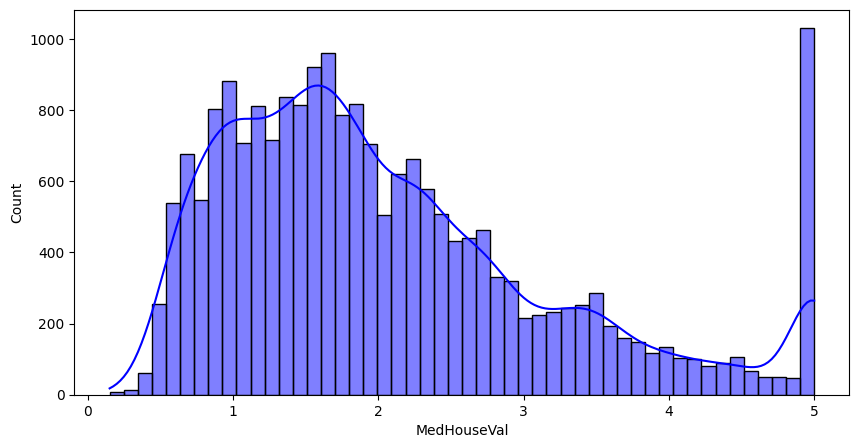

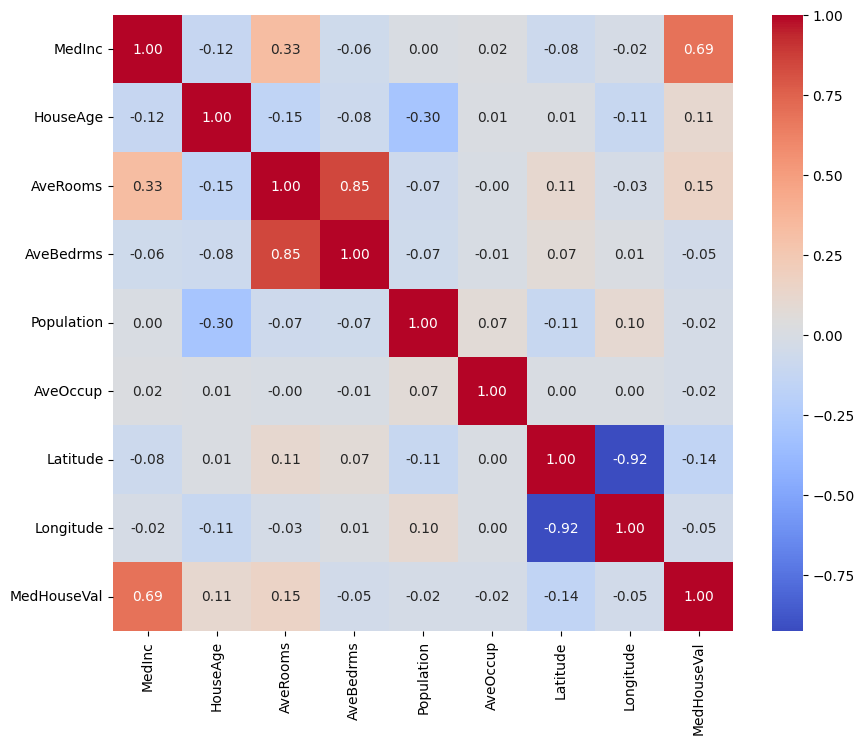

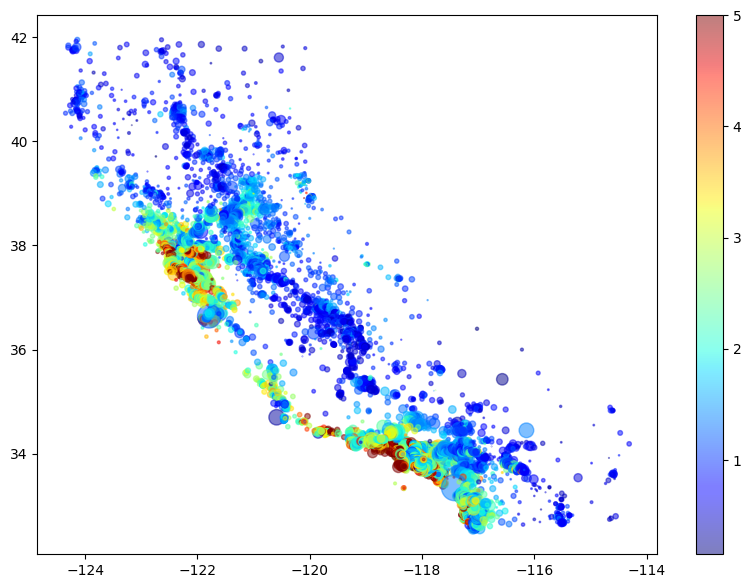

mae = 0.5332001304956553
rmse = 0.7455813830127764
r2 = 0.5757877060324508
      Real      Pred
0  0.47700  0.719123
1  0.45800  1.764017
2  5.00001  2.709659
3  2.18600  2.838926
4  2.78000  2.604657
5  1.58700  2.011754
6  1.98200  2.645500
7  1.57500  2.168755
8  3.40000  2.740746
9  4.46600  3.915615


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

data = fetch_california_housing(as_frame=True)
df= data.frame

print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())
df=df.fillna(df.median())
print("Дубль",df.duplicated().sum())
df = df.drop_duplicates()
plt.figure(figsize=(10,5))
sns.histplot(df['MedHouseVal'],kde=True,bins=50, color='blue')
plt.show()
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(),annot=True, cmap='coolwarm',fmt=".2f")
plt.show()
plt.figure(figsize=(10,7))
plt.scatter(df['Longitude'],df['Latitude'],c=df['MedHouseVal'],cmap='jet',s=df['Population']/100,alpha=0.5)
plt.colorbar()
plt.show()

X = df.drop(columns=['MedHouseVal'])
y=df['MedHouseVal']
X_train, X_test,y_train,y_test= train_test_split(X,y ,test_size=0.2,random_state=42)
lr=LinearRegression()
lr.fit(X_train,y_train)
pred= lr.predict(X_test)
print("mae =",mean_absolute_error(y_test,pred))
print("rmse =", np.sqrt(mean_squared_error(y_test,pred)))
print("r2 =",r2_score(y_test,pred))

itog= pd.DataFrame({'Real':y_test.values,'Pred':pred})
print(itog.head(10))
